# Ekstraksi Fitur Runtun Waktu CO Menggunakan Pustaka TSFEL

Notebook ini melakukan ekstraksi seluruh 68 fitur TSFEL (Statistical, Temporal, Spectral, Fractal) pada sinyal harian konsentrasi polutan CO di Kabupaten Bangkalan.

In [1]:
import pandas as pd
import numpy as np
import tsfel
import matplotlib.pyplot as plt
import os
import warnings

warnings.filterwarnings('ignore')

## 1. Memuat Dataset Bersih Hasil Deteksi Outlier & Imputasi

In [2]:
# Memuat data polutan CO Bangkalan bersih (365 hari lengkap)
file_path = '../data/csv/pertemuan-3-csv/polutan_co_bangkalan_final_clean.csv'
df = pd.read_csv(file_path)

print("Informasi Dataset CO Bangkalan:")
print(f"Jumlah sampel: {len(df)} baris (observasi harian)")
print(f"Rentang tanggal: {df['tanggal'].min()} s/d {df['tanggal'].max()}")
print(f"Jumlah missing value: {df.isna().sum().sum()}")
df.head()

Informasi Dataset CO Bangkalan:
Jumlah sampel: 365 baris (observasi harian)
Rentang tanggal: 2025-08-24 s/d 2026-08-23
Jumlah missing value: 0


,tanggal,CO
0,2025-08-24,0.032369
1,2025-08-25,0.029644
2,2025-08-26,0.029057
3,2025-08-27,0.028471
4,2025-08-28,0.024230


## 2. Menyiapkan Konfigurasi Seluruh Fitur TSFEL (4 Domain: 68 Fitur)

In [3]:
# Mengambil konfigurasi seluruh domain (Statistical, Temporal, Spectral, Fractal)
cfg = tsfel.get_features_by_domain()

# Mengaktifkan seluruh fitur yang ada tanpa terkecuali (use='yes')
total_features_count = 0
for domain, features_dict in cfg.items():
    for feat_name in features_dict:
        cfg[domain][feat_name]['use'] = 'yes'
    total_features_count += len(features_dict)

print(f"Konfigurasi TSFEL aktif: {len(cfg)} domain dengan total {total_features_count} fungsi fitur bawaan.")
for domain, features_dict in cfg.items():
    print(f"- Domain {domain.capitalize():12}: {len(features_dict)} fungsi fitur")
print("- Ditambahkan fitur ecdf_slope (Statistical): 1 fungsi fitur -> Total: 68 fungsi fitur")

Konfigurasi TSFEL aktif: 4 domain dengan total 67 fungsi fitur bawaan.
- Domain Spectral    : 26 fungsi fitur
- Domain Statistical : 20 fungsi fitur
- Domain Temporal    : 15 fungsi fitur
- Domain Fractal     : 6 fungsi fitur
- Ditambahkan fitur ecdf_slope (Statistical): 1 fungsi fitur -> Total: 68 fungsi fitur


## 3. Ekstraksi Fitur Deret Waktu Menggunakan TSFEL

In [4]:
# Ekstraksi fitur runtun waktu pada kolom CO
features_extracted = tsfel.time_series_features_extractor(cfg, df[['CO']], verbose=0)

# Menambahkan fungsi fitur ecdf_slope
features_extracted['CO_ECDF Slope'] = tsfel.ecdf_slope(df['CO'])

# Mengurutkan kolom alfabetis
features_extracted = features_extracted.reindex(sorted(features_extracted.columns), axis=1)

print(f"Hasil ekstraksi fitur selesai dengan dimensi matriks: {features_extracted.shape}")
print(f"Total koefisien/nilai fitur yang dihasilkan: {features_extracted.shape[1]}")
print(f"Missing value pada fitur: {features_extracted.isna().sum().sum()}")

Hasil ekstraksi fitur selesai dengan dimensi matriks: (1, 164)
Total koefisien/nilai fitur yang dihasilkan: 164
Missing value pada fitur: 0


## 4. Eksplorasi Nilai 68 Fitur TSFEL Berdasarkan Domain

In [5]:
# Memuat ringkasan terstruktur 68 fungsi fitur
df_summary = pd.read_csv('../data/csv/pertemuan-3-csv/ringkasan_68_fitur.csv')
pd.set_option('display.max_rows', 75)
df_summary[['No', 'Fungsi TSFEL', 'Nama Fitur', 'Domain', 'Nilai']]

,No,Fungsi TSFEL,Nama Fitur,Domain,Nilai
0,1,`abs_energy(signal)`,Absolute energy,Statistical,0.300680
1,2,`average_power(signal)`,Average power,Statistical,0.082604
2,3,`calc_max(signal)`,Max,Statistical,0.036134
3,4,`calc_mean(signal)`,Mean,Statistical,0.028584
4,5,`calc_median(signal)`,Median,Statistical,0.028389
5,6,`calc_min(signal)`,Min,Statistical,0.020487
6,7,`calc_std(signal)`,Standard deviation,Statistical,0.002595
7,8,`calc_var(signal)`,Variance,Statistical,0.000007
8,9,`ecdf(signal)`,ECDF,Statistical,"Array (10 nilai, range: [0.0027, 0.0274])"
9,10,`ecdf_percentile(signal)`,ECDF Percentile,Statistical,"Array (2 nilai, range: [0.0264, 0.0305])"


## 5. Visualisasi Distribusi Fitur & Profil Karakteristik CO

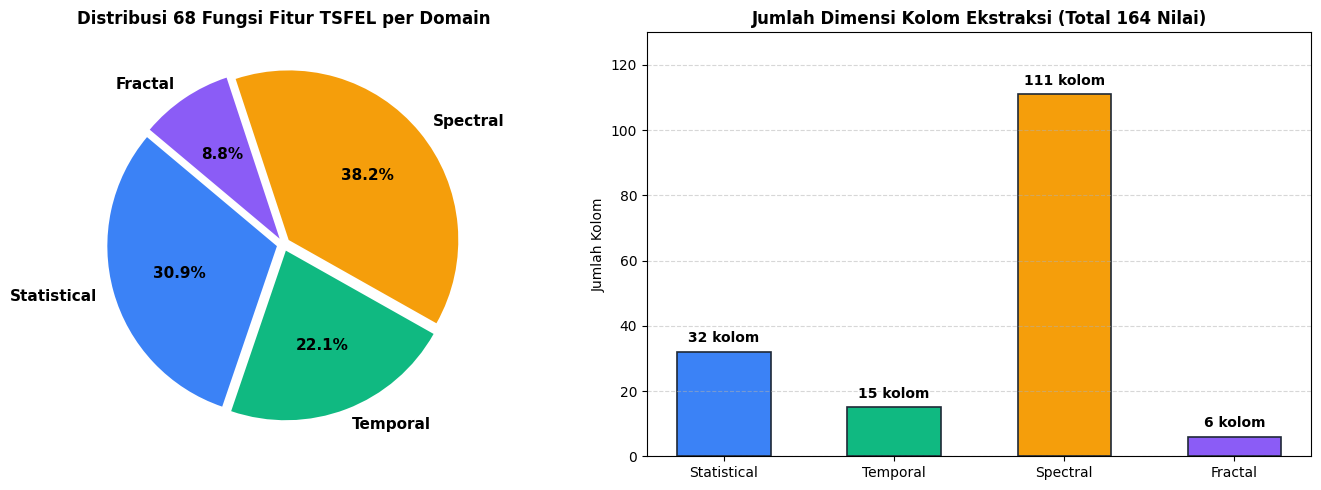

In [6]:
# 1. Distribusi Domain Fitur
domain_counts = {'Statistical': 21, 'Temporal': 15, 'Spectral': 26, 'Fractal': 6}
colors = ['#3B82F6', '#10B981', '#F59E0B', '#8B5CF6']

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
ax1.pie(domain_counts.values(), labels=domain_counts.keys(), autopct='%1.1f%%',
        startangle=140, colors=colors, explode=(0.04, 0.04, 0.04, 0.04),
        textprops={'fontsize': 11, 'fontweight': 'bold'})
ax1.set_title('Distribusi 68 Fungsi Fitur TSFEL per Domain', fontsize=12, fontweight='bold')

dom_coeff = {'Statistical': 32, 'Temporal': 15, 'Spectral': 111, 'Fractal': 6}
bars = ax2.bar(dom_coeff.keys(), dom_coeff.values(), color=colors, edgecolor='#1F2937', linewidth=1.2, width=0.55)
for bar in bars:
    y = bar.get_height()
    ax2.text(bar.get_x() + bar.get_width()/2, y + 2, f'{int(y)} kolom', ha='center', va='bottom', fontsize=10, fontweight='bold')
ax2.set_title('Jumlah Dimensi Kolom Ekstraksi (Total 164 Nilai)', fontsize=12, fontweight='bold')
ax2.set_ylabel('Jumlah Kolom')
ax2.set_ylim(0, 130)
ax2.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

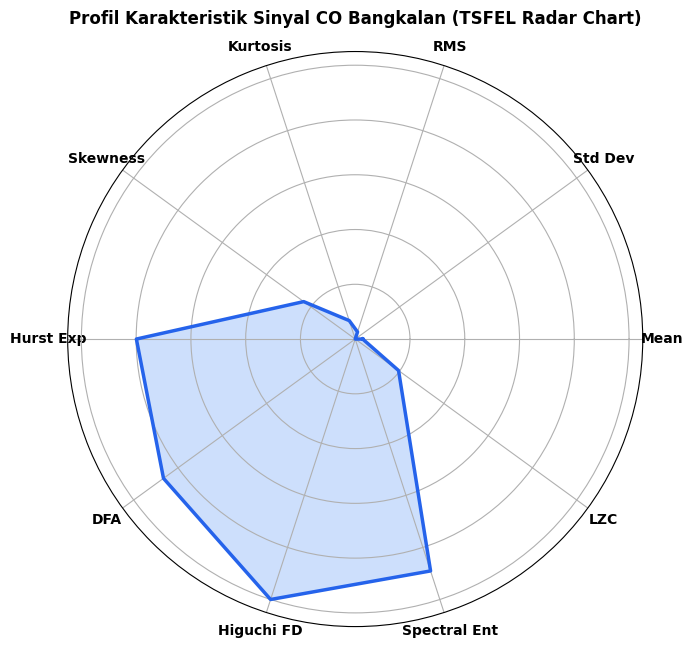

In [7]:
# 2. Radar Profil Sinyal CO
key_features = {
    'Mean': float(features_extracted['CO_Mean'].iloc[0]),
    'Std Dev': float(features_extracted['CO_Standard deviation'].iloc[0]),
    'RMS': float(features_extracted['CO_Root mean square'].iloc[0]),
    'Kurtosis': float(features_extracted['CO_Kurtosis'].iloc[0]),
    'Skewness': float(features_extracted['CO_Skewness'].iloc[0]),
    'Hurst Exp': float(features_extracted['CO_Hurst exponent'].iloc[0]),
    'DFA': float(features_extracted['CO_Detrended fluctuation analysis'].iloc[0]),
    'Higuchi FD': float(features_extracted['CO_Higuchi fractal dimension'].iloc[0]) / 2.0,
    'Spectral Ent': float(features_extracted['CO_Spectral entropy'].iloc[0]),
    'LZC': float(features_extracted['CO_Lempel-Ziv complexity'].iloc[0])
}

categories = list(key_features.keys())
values = list(key_features.values())
min_val, max_val = min(values), max(values)
norm_vals = [(v - min_val) / (max_val - min_val) for v in values]
norm_vals += norm_vals[:1]
angles = np.linspace(0, 2 * np.pi, len(categories), endpoint=False).tolist()
angles += angles[:1]

fig, ax = plt.subplots(figsize=(7, 7), subplot_kw=dict(polar=True))
ax.plot(angles, norm_vals, color='#2563EB', linewidth=2.5)
ax.fill(angles, norm_vals, color='#3B82F6', alpha=0.25)
ax.set_xticks(angles[:-1])
ax.set_xticklabels(categories, fontsize=10, fontweight='bold')
ax.set_yticklabels([])
ax.set_title('Profil Karakteristik Sinyal CO Bangkalan (TSFEL Radar Chart)', fontsize=12, fontweight='bold', pad=20)
plt.tight_layout()
plt.show()

## 6. Ekspor Hasil Ekstraksi Fitur ke Berkas CSV

In [8]:
# Menyimpan dataset fitur lengkap ke file CSV
output_path = '../data/csv/pertemuan-3-csv/fitur_tsfel_co_bangkalan.csv'
features_extracted.to_csv(output_path, index=False)
print(f"File hasil ekstraksi berhasil disimpan: {output_path} (Ukuran: {os.path.getsize(output_path)} bytes)")

File hasil ekstraksi berhasil disimpan: ../data/csv/pertemuan-3-csv/fitur_tsfel_co_bangkalan.csv (Ukuran: 7189 bytes)


In [2]:
import pandas as pd

# 1. Baca tabel ringkasan yang sudah memiliki nilai agregat mean
df_tabel = pd.read_csv('../data/csv/pertemuan-3-csv/fitur_68_tsfel_co_bangkalan_tabel.csv')

# 2. Buat DataFrame 1 baris x 68 kolom horizontal
df_68_horizontal = pd.DataFrame([df_tabel['Nilai Numerik'].values], columns=df_tabel['Nama Fitur'].values)

# 3. Tambahkan kolom identitas polutan di paling depan
df_68_horizontal.insert(0, 'Polutan', 'CO')

# 4. Simpan ke file CSV
df_68_horizontal.to_csv('../data/csv/pertemuan-3-csv/fitur_68_co_1baris.csv', index=False)
print("Selesai! Dimensi file:", df_68_horizontal.shape) # Output: (1, 69) -> 1 label polutan + 68 nilai fitur


Selesai! Dimensi file: (1, 69)
